In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

,user,item,rating
0,2,1,3.422627
1,1,3,4.827346
2,9,4,3.367856
3,7,0,5.051662
4,4,2,5.741973


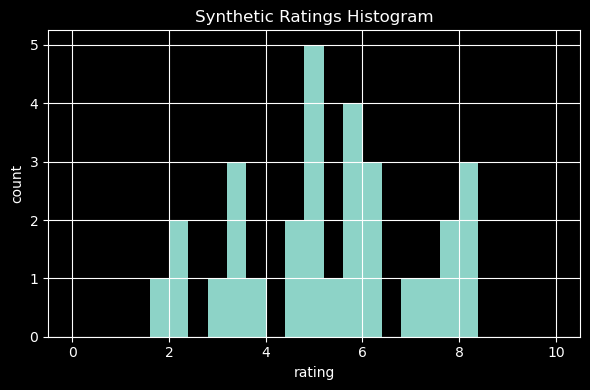

item,0,1,2,3,4
user,,,,,
0,NaN,5.215810,NaN,NaN,3.313295
1,1.745232,NaN,NaN,4.827346,7.815793
2,8.131241,3.422627,3.812285,NaN,4.897446
3,5.900335,NaN,4.978960,4.419481,NaN
4,NaN,NaN,5.741973,NaN,5.601566
5,6.355375,2.153545,8.172686,NaN,NaN
6,5.195124,7.793339,7.311609,5.627529,2.013015
7,5.051662,NaN,6.195565,NaN,NaN
8,NaN,4.597505,NaN,7.169248,NaN


In [35]:
# Global parameters
n_users = 10
n_items = 5
latent_dim = 16
n_ratings = 30

assert n_ratings <= n_users * n_items, "Too many ratings for unique user–item pairs"

# True (hidden) parameters
true_global_mean = 5.0
true_user_emb = np.random.normal(0, 0.6, size=(n_users, latent_dim))
true_item_emb = np.random.normal(0, 0.6, size=(n_items, latent_dim))

# -------------------------------------------------
# Sample UNIQUE user–item pairs (no duplicates)
# -------------------------------------------------
all_pairs = np.array(
    [(u, i) for u in range(n_users) for i in range(n_items)]
)

chosen_idx = np.random.choice(
    len(all_pairs),
    size=n_ratings,
    replace=False
)

user_ids = all_pairs[chosen_idx, 0]
item_ids = all_pairs[chosen_idx, 1]

# -------------------------------------------------
# Generate ratings with noise
# -------------------------------------------------
ratings = (
    true_global_mean
    + np.sum(true_user_emb[user_ids] * true_item_emb[item_ids], axis=1)
    + np.random.normal(0, 1.0, size=n_ratings)
)

ratings = np.clip(ratings, 0, 10)

df = pd.DataFrame(
    {
        "user": user_ids.astype("int64"),
        "item": item_ids.astype("int64"),
        "rating": ratings.astype("float64"),
    }
)

display(df.head())

# Sanity check: no duplicates
assert not df.duplicated(subset=["user", "item"]).any()

plt.figure(figsize=(6, 4))
pd.Series(ratings).hist(bins=25, range=(0,10))
plt.title("Synthetic Ratings Histogram")
plt.xlabel("rating")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# -----------------------------
# 1) Build user–item matrix (NaNs for missing)
# -----------------------------
R = pd.pivot_table(
    df,
    index="user",
    columns="item",
    values="rating",
    aggfunc="mean"
).sort_index(axis=0).sort_index(axis=1)

R

RMSE (observed cells only): 0.5156
MAE  (observed cells only): 0.3190


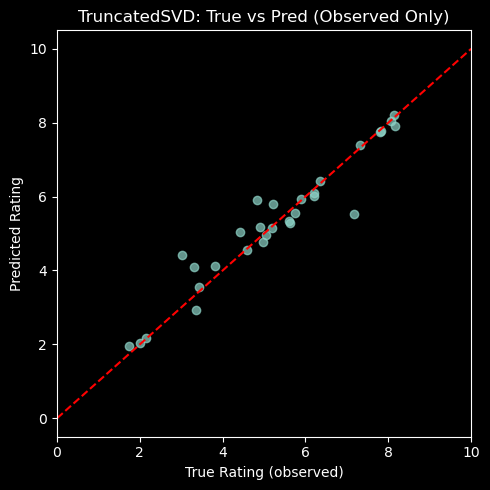

Top recommendations for user 0 (unrated items only):


item
0    5.827672
2    5.805374
3    5.162226
Name: 0, dtype: float64

In [36]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error

global_mean = df["rating"].mean()

# Mean-center, keep NaNs
R_centered = R - global_mean

# Fill NaNs with 0 ONLY for factorization
R_centered_filled = R_centered.fillna(0.0)

# -----------------------------
# 2) Truncated SVD (sklearn)
# -----------------------------
k = 3
svd = TruncatedSVD(n_components=k, random_state=0)
U_svd = svd.fit_transform(R_centered_filled.values)   # (n_users, k)
V_svd = svd.components_                               # (k, n_items)

# -----------------------------
# 3) Reconstruct predictions
# -----------------------------
R_hat_centered = U_svd @ V_svd
R_hat = R_hat_centered + global_mean

R_hat_df = pd.DataFrame(R_hat, index=R.index, columns=R.columns)

# -----------------------------
# 4) Evaluate ONLY on observed entries (no NaNs)
# -----------------------------
obs_mask = ~R.isna()

true_obs = R.values[obs_mask.values]
pred_obs = R_hat_df.values[obs_mask.values]

rmse = np.sqrt(mean_squared_error(true_obs, pred_obs))
mae = mean_absolute_error(true_obs, pred_obs)

print(f"RMSE (observed cells only): {rmse:.4f}")
print(f"MAE  (observed cells only): {mae:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(true_obs, pred_obs, alpha=0.7)
plt.plot([0, 10], [0, 10], "r--")
plt.xlim(0,10)
plt.xlabel("True Rating (observed)")
plt.ylabel("Predicted Rating")
plt.title("TruncatedSVD: True vs Pred (Observed Only)")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Recommend: choose highest preds among UNOBSERVED items
# -----------------------------
def recommend_top_n(user_id, n=3):
    # Candidate items are those the user did NOT rate (NaNs in original R)
    unrated_items = R.columns[R.loc[user_id].isna()]
    scores = R_hat_df.loc[user_id, unrated_items].sort_values(ascending=False)
    return scores.head(n)

print("Top recommendations for user 0 (unrated items only):")
display(recommend_top_n(0, n=10))